# Data Exploration: Welltory COVID-19 and Wearables Dataset

Ben Dushnitzky, AIPI 510 Week 4

The assignment said this dataset is messy and that's accurate. This notebook is me working through what
is in it, what is wrong with it, and what I would have to fix before using it for anything. I spend most
of the time on the HRV measurements table since that is the one the study was actually built around.

## 1. Data context and sampling

The data comes from https://github.com/Welltory/hrv-covid19. Welltory is a consumer app that measures
heart rate variability, and in 2020 they asked users who had COVID symptoms to keep logging measurements
so researchers could look for patterns. It is released under Creative Commons and the repo includes a
consent file and a `datatypes.md` dictionary, which is where I got most of my understanding of the
columns.

One thing that took me a while to appreciate is that there are three totally different collection methods
mixed in here:

- HRV was measured either with a Bluetooth chest strap or with the phone camera, using
  photoplethysmography (you put your finger over the lens and the app picks up blood volume changes to
  find each heartbeat). The camera method is noisier. There is no column telling you which one was used,
  which is annoying.
- Wearable data came from whatever device the person already owned, synced through Apple Health or Google
  Fit. Apple Watch and Garmin do not measure the same things, and that explains a lot of the emptiness I
  found later.
- Symptoms were typed in by the user with no validation at all.

For lineage: the raw beat intervals go through Welltory's own filtering and then get turned into the
metrics stored here. So these are processed numbers and I cannot see inside their algorithm. The one
useful thing is that `rr_data` still holds the raw intervals, so there is at least a way to check their
output against its own source.

On sampling, this is a convenience sample. Everyone in it owned a smartphone, installed a health app, and
volunteered for a study. That skews toward younger and wealthier people, and anyone sick enough to be
hospitalised is not going to be logging HRV measurements, so the sample is probably tilted toward milder
cases. There is no control group, COVID status is self-reported at a time when tests were hard to get,
and people measured whenever they felt like it. All of that limits what can honestly be concluded.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

if not os.path.exists("hrv-covid19"):
    os.system("git clone --depth 1 https://github.com/Welltory/hrv-covid19.git")
DATA = "hrv-covid19/data/"

participants = pd.read_csv(DATA + "participants.csv")
hrv          = pd.read_csv(DATA + "hrv_measurements.csv", low_memory=False)
surveys      = pd.read_csv(DATA + "surveys.csv")
scales       = pd.read_csv(DATA + "scales_description.csv")
wearables    = pd.read_csv(DATA + "wearables.csv")
heart_rate   = pd.read_csv(DATA + "heart_rate.csv", low_memory=False)

tables = {"participants": participants, "hrv_measurements": hrv, "surveys": surveys,
          "scales_description": scales, "wearables": wearables, "heart_rate": heart_rate}

summary = []
for name, df in tables.items():
    users = df["user_code"].nunique() if "user_code" in df.columns else None
    summary.append({"table": name, "rows": len(df), "columns": df.shape[1], "users": users})
pd.DataFrame(summary)

,table,rows,columns,users
0,participants,185,8,185.0
1,hrv_measurements,3245,22,185.0
2,surveys,2259,5,111.0
3,scales_description,148,4,NaN
4,wearables,3098,18,79.0
5,heart_rate,523783,4,79.0


## 2. Structure, and what the columns actually mean

Everything joins on `user_code`, which is the anonymised participant ID. `participants` has one row per
person and the others have one row per measurement or per day. `scales_description` is not data at all,
it is a codebook that tells you what the numeric `value` in `surveys` means.

The coverage is really uneven. 185 people, but 3,245 HRV measurements versus 523,783 heart rate readings.
If I joined all of these into one wide table most of it would be empty, so I kept them separate and only
joined what I needed.

HRV itself is the variation in the time between heartbeats. A relaxed body varies a lot and stress or
illness flattens it out. The columns come in two groups, time-domain and frequency-domain:

| Column | What it is |
|---|---|
| `meanrr` | Average gap between beats in ms. `bpm` is just 60000 / meanrr |
| `sdnn` | Standard deviation of the beat intervals, so overall variability |
| `rmssd` | Root mean square of successive differences. Short-term variability, mostly parasympathetic (the "rest and digest" side) |
| `pnn50` | Percent of consecutive beats that differ by more than 50ms. Also parasympathetic |
| `mode`, `amo` | Most common interval, and what share of beats land in that bin. High `amo` means a rigid rhythm |
| `hf` | High frequency power, 0.15-0.4 Hz, follows breathing |
| `lf` | Low frequency power, 0.04-0.15 Hz, mixed signal |
| `vlf` | Very low frequency power, below 0.04 Hz |
| `lfhf` | The LF/HF ratio. Sometimes described as sympathovagal balance, though that reading is argued about |
| `total_power` | Total power across the bands |

`how_feel`, `how_mood` and `how_sleep` are ratings the user gave at the time of measuring, and `tags` are
free-text labels like "COVID-19" or "Workout".

Something to keep in mind: `rmssd`, `pnn50` and `hf` are all getting at the same parasympathetic thing
from different angles, so I would expect them to be strongly correlated. I check that later.

In [2]:
print(hrv.shape)
display(hrv.drop(columns=["rr_data"]).head(3))
hrv.drop(columns=["rr_data"]).dtypes.to_frame("dtype").T

(3245, 22)


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.9,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.0,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.1,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags
dtype,str,str,str,str,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,str


## 3. Descriptive statistics

In [3]:
hrv_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "amo",
            "lf", "hf", "vlf", "lfhf", "total_power"]
display(hrv[hrv_cols].describe().T.round(2))
hrv[hrv_cols].skew().sort_values(ascending=False).round(2).to_frame("skew")

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.26,12.20,44.00,65.00,72.00,81.00,125.00
meanrr,3245.0,839.60,137.42,477.73,742.49,829.10,925.93,1346.74
sdnn,3245.0,52.49,29.37,9.52,32.58,46.92,64.41,206.63
rmssd,3245.0,52.81,39.35,6.34,28.98,42.87,62.48,310.80
pnn50,3245.0,20.62,18.59,0.00,6.06,16.16,29.29,91.92
amo,3245.0,46.79,16.42,12.00,35.00,45.00,57.00,98.00
lf,3245.0,927.04,1455.42,2.00,151.00,423.00,1059.00,15522.00
hf,3245.0,1125.04,2490.54,4.00,158.00,380.00,993.00,33490.00
vlf,3245.0,578.23,876.68,1.00,116.00,293.00,693.00,18468.00
lfhf,3245.0,2.40,5.75,0.03,0.40,0.86,1.97,105.62


,skew
lfhf,7.98
vlf,6.05
hf,5.34
lf,3.80
total_power,3.79
rmssd,2.66
sdnn,1.72
pnn50,1.41
amo,0.53
bpm,0.48


The time-domain columns look fine. `bpm` goes from 44 to 125, mean 73 and median 72, so pretty symmetric.

The frequency columns are a different animal. `hf` runs from 4 all the way to 33,490, and the mean is
1,125 while the median is only 380. Whenever the mean is three times the median you know there is a long
tail pulling it up, and the skew numbers confirm it: vlf 6.1, hf 5.3, lf 3.8.

This is not an error, HRV power spectra genuinely look like this. But it does mean the mean and standard
deviation are not telling me much for these columns, and it is going to cause problems for any outlier
rule built on standard deviations. I come back to that below.

## 4. Data quality assessment

Going through the standard quality dimensions. The summary up front is that the structure of this data is
solid but the contents are not, and almost every problem traces back to something a user typed in
themselves.

In [4]:
# Profiling: how complete is each table
summary = []
for name, df in tables.items():
    worst = df.isna().mean().idxmax()
    summary.append({"table": name,
                    "overall_missing_%": round(df.isna().mean().mean() * 100, 1),
                    "emptiest_column": worst,
                    "that_column_%": round(df[worst].isna().mean() * 100, 1)})
display(pd.DataFrame(summary).sort_values("overall_missing_%", ascending=False))

(wearables.isna().mean() * 100).round(1).sort_values(ascending=False).head(6).to_frame("missing_%")

,table,overall_missing_%,emptiest_column,that_column_%
4,wearables,48.2,average_spo2_value,98.7
1,hrv_measurements,4.0,how_sleep,54.8
0,participants,3.9,symptoms_onset,20.5
2,surveys,0.0,user_code,0.0
3,scales_description,0.0,Scale,0.0
5,heart_rate,0.0,user_code,0.0


,missing_%
average_spo2_value,98.7
body_temperature_avg,97.9
average_environment_exposure,95.2
average_headphone_exposure,92.6
stand_hours_total,82.9
active_calories_burned,61.3


In [5]:
# Accuracy check. bpm should be exactly 60000/meanrr, so this tests the data against itself.
gap = (hrv["bpm"] - 60000 / hrv["meanrr"]).abs()
print("median disagreement:", round(gap.median(), 3), "bpm")
print("rows off by more than 5 bpm:", (gap > 5).sum())

# Now the self-reported dates, which have no equivalent check
onset = pd.to_datetime(participants["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
hrv_dt = pd.to_datetime(hrv["measurement_datetime"])
print()
print("symptom onset dates range from", onset.min().date(), "to", onset.max().date())
print("but the study only ran from  ", hrv_dt.min().date(), "to", hrv_dt.max().date())
impossible = onset[(onset < "2019-12-01") | (onset > "2020-07-01")]
print("onset dates that fall outside the study:", len(impossible))
print(sorted(impossible.dt.date.tolist()))

median disagreement: 0.332 bpm
rows off by more than 5 bpm: 0

symptom onset dates range from 1967-01-30 to 2022-04-21
but the study only ran from   2019-12-31 to 2020-06-19
onset dates that fall outside the study: 13
[datetime.date(1967, 1, 30), datetime.date(1968, 8, 15), datetime.date(1975, 3, 28), datetime.date(1977, 11, 20), datetime.date(1981, 11, 26), datetime.date(1982, 12, 16), datetime.date(1984, 4, 5), datetime.date(1987, 7, 7), datetime.date(1993, 1, 1), datetime.date(1999, 3, 6), datetime.date(2000, 6, 7), datetime.date(2021, 4, 1), datetime.date(2022, 4, 21)]


In [6]:
# Consistency: the codebook is supposed to join onto surveys by the scale name
print("codebook keys with hidden whitespace:", [s for s in scales["Scale"].unique() if s != s.strip()])
print("scales with no codebook match, plain join:", sorted(set(surveys["scale"]) - set(scales["Scale"])))
print("same thing after stripping whitespace:   ", sorted(set(surveys["scale"]) - set(scales["Scale"].str.strip())))

# Are the units consistent?
hw = participants[["height", "weight"]].dropna().head(4).copy()
hw["height_inches"] = (hw["height"] / 2.54).round(2)
hw["weight_pounds"] = (hw["weight"] * 2.20462).round(2)
display(hw)

# Integrity: does every user_code actually exist in participants
known = set(participants["user_code"])
for name, df in tables.items():
    if "user_code" in df.columns:
        orphans = set(df["user_code"]) - known
        print(f"{name:20s} users={df['user_code'].nunique():4d}  orphaned={len(orphans)}")
print("duplicate user_code in participants:", participants["user_code"].duplicated().sum())

codebook keys with hidden whitespace: ['S_HRA_MONTH\n\xa0']
scales with no codebook match, plain join: []
same thing after stripping whitespace:    []


,height,weight,height_inches,weight_pounds
0,170.18,96.162,67.00,212.00
1,174.00,77.300,68.50,170.42
2,178.00,92.000,70.08,202.83
3,169.00,60.000,66.54,132.28


participants         users= 185  orphaned=0
hrv_measurements     users= 185  orphaned=0
surveys              users= 111  orphaned=0
wearables            users=  79  orphaned=0
heart_rate           users=  79  orphaned=0
duplicate user_code in participants: 0


Taking those in turn.

Completeness. `average_spo2_value` is 98.7% missing and `body_temperature_avg` is 97.9% missing, which
looks alarming until you think about what those columns are. They only get filled if the person owned a
device that measures blood oxygen or skin temperature, and in early 2020 hardly anyone did.
`basal_calories_burned` is 0% missing because every platform reports it. So this is missing not at random
— whether a value exists depends on what hardware someone bought. That matters for what I do about it
later.

Accuracy. The good part: `bpm` agrees with `60000/meanrr` to within 0.33 bpm and not a single row is off
by more than 5. The machine-generated columns hold together.

The bad part is the self-reported stuff. Thirteen people gave symptom onset dates that fall completely
outside the study window — 1967, 1984, 1999, 2021, 2022 — when the study only ran from December 2019 to
June 2020. These were free-text fields with no validation. My guess is people typed a birth date, given
how many land in the 60s through 90s. This is the worst accuracy problem in the dataset and it matters a
lot, because `symptoms_onset` is what my engineered feature depends on.

Consistency. One codebook key is stored as `'S_HRA_MONTH\n\xa0'`, so a trailing newline and a
non-breaking space. Probably pasted out of a spreadsheet. Every scale does match once you strip the
whitespace, but the obvious version of that join would quietly drop rows instead of throwing an error,
which is the kind of bug that does not announce itself.

The heights and weights are also interesting. They convert to suspiciously round imperial numbers — 170.18
cm is exactly 67 inches and 96.162 kg is exactly 212 pounds. So people entered a mix of units and it all
got converted on the way in. The three decimal places are just an artifact of that conversion, not real
precision.

Integrity is the one clean part. No orphaned user codes anywhere, no duplicate participant IDs. Whoever
exported this did the relational side properly.

Lineage and provenance, pulled together, because it decides how much I trust each column:

| Stage | What happens | Why it matters |
|---|---|---|
| Collection | Phone camera or chest strap | Two methods, different noise levels, and nothing records which |
| Processing | Welltory's own filtering | Cannot audit it, but `rr_data` lets me at least sanity check it |
| Wearables | Third party devices via Apple Health or Google Fit | Different vendors define things like "resting pulse" differently |
| Self-report | Typed into the app | No validation, which is where the 1967 date came from |
| Publication | Anonymised, Creative Commons | Nothing can be checked against a medical record |

Short version: trust the HRV columns, be careful with the wearables, and treat anything self-reported
with suspicion.

## 5. Missing values

The rule I tried to follow is that why a value is missing should decide what to do about it. Filling in a
number where the blank means something structural is just making data up.

In [7]:
for col in ["how_feel", "how_mood", "how_sleep"]:
    print(col, "->", dict(hrv[col].value_counts(dropna=False).sort_index()))
print()
pd.crosstab(hrv["time_of_day"], hrv["how_sleep"].isna(),
            rownames=["time_of_day"], colnames=["how_sleep missing"])

how_feel -> {-2: np.int64(124), -1: np.int64(857), 0: np.int64(1975), 1: np.int64(237), 2: np.int64(52)}
how_mood -> {-2: np.int64(96), -1: np.int64(471), 0: np.int64(2335), 1: np.int64(272), 2: np.int64(71)}
how_sleep -> {-2.0: np.int64(50), -1.0: np.int64(238), 0.0: np.int64(967), 1.0: np.int64(180), 2.0: np.int64(31), nan: np.int64(1779)}



how_sleep missing,False,True
time_of_day,,
day,25,781
evening,0,701
morning,1440,27
night,1,270


I nearly got caught out here. `how_feel` and `how_mood` have -1 and -2 in them, and my first thought was
that those are sentinel codes for missing data, since that is a common convention. But look at the
spread: -2, -1, 0, 1, 2, with most of the values sitting at 0. That is a five point Likert scale, not a
missing code. If I had stripped the negatives I would have deleted exactly the measurements taken when
people felt bad, which is the entire thing the study was trying to capture.

`how_sleep` is a different story. The crosstab shows it is filled in for almost every morning measurement
and almost never any other time, because it only gets asked in the morning. So it is missing by design,
and imputing it would mean inventing an answer to a question nobody was asked.

In [8]:
plan = pd.DataFrame([
    ["how_feel / how_mood", "0%", "Likert scale points, not sentinels", "leave alone"],
    ["how_sleep", "54.8%", "only asked in the morning", "leave missing"],
    ["tags", "32.2%", "blank means no tag was picked", "fill with empty string"],
    ["symptoms_onset", "20.5%", "never reported", "leave missing"],
    ["average_spo2_value", "98.7%", "device could not measure it", "drop the column"],
    ["body_temperature_avg", "97.9%", "device could not measure it", "drop the column"],
], columns=["column", "missing", "why", "what I did"])
display(plan)

hrv_clean = hrv.copy()
hrv_clean["tags"] = hrv_clean["tags"].fillna("")
too_sparse = wearables.columns[wearables.isna().mean() > 0.90]
wearables_clean = wearables.drop(columns=too_sparse)
print("dropped from wearables:", list(too_sparse))

,column,missing,why,what I did
0,how_feel / how_mood,0%,"Likert scale points, not sentinels",leave alone
1,how_sleep,54.8%,only asked in the morning,leave missing
2,tags,32.2%,blank means no tag was picked,fill with empty string
3,symptoms_onset,20.5%,never reported,leave missing
4,average_spo2_value,98.7%,device could not measure it,drop the column
5,body_temperature_avg,97.9%,device could not measure it,drop the column


dropped from wearables: ['average_spo2_value', 'body_temperature_avg', 'average_headphone_exposure', 'average_environment_exposure']


On why I did not impute the sparse wearable columns: the easy thing would be a median fill. But whether
`average_spo2_value` exists depends on whether someone could afford a watch that measures it, so filling
the blanks with the median of the people who could afford one would be handing their physiology to
everyone else. A model trained on that would partly be learning about income rather than health, so I
dropped the columns instead.

## 6. Duplicates

None of the tables have a fully duplicated row, so calling `drop_duplicates()` straight off does nothing.
The duplicates are on the natural keys instead, which you only find if you go looking for them.

In [9]:
keys = {"heart_rate": ["user_code", "datetime"],
        "hrv_measurements": ["user_code", "measurement_datetime"],
        "surveys": ["user_code", "scale", "created_at"],
        "wearables": ["user_code", "day"]}
report = []
for name, df in tables.items():
    on_key = df.duplicated(keys[name]).sum() if name in keys else None
    report.append({"table": name, "exact_duplicate_rows": df.duplicated().sum(),
                   "duplicates_on_key": on_key})
display(pd.DataFrame(report))

heart_rate[heart_rate.duplicated(["user_code", "datetime"], keep=False)].sort_values(
    ["user_code", "datetime"]).head(4)

,table,exact_duplicate_rows,duplicates_on_key
0,participants,0,NaN
1,hrv_measurements,0,0.0
2,surveys,0,24.0
3,scales_description,0,NaN
4,wearables,0,0.0
5,heart_rate,0,7330.0


,user_code,datetime,heart_rate,is_resting
68,01bad5a519,2020-05-12 20:56:53,65,0
69,01bad5a519,2020-05-12 20:56:53,66,0
72,01bad5a519,2020-05-14 03:37:01,68,0
73,01bad5a519,2020-05-14 03:37:01,69,0


In [10]:
# Average the heart rate collisions instead of just keeping whichever came first
heart_rate_clean = (heart_rate.groupby(["user_code", "datetime"], as_index=False)
                    .agg({"heart_rate": "mean", "is_resting": "max"}))
# For repeated survey answers keep the later one
surveys_clean = surveys.drop_duplicates(["user_code", "scale", "created_at"], keep="last")
print("heart_rate:", len(heart_rate), "->", len(heart_rate_clean))
print("surveys:   ", len(surveys), "->", len(surveys_clean))

heart_rate: 523783 -> 516453
surveys:    2259 -> 2235


The 7,330 heart rate collisions are the same person at the same second with two different readings. That
smells like a sync artifact, the same reading coming in twice from two sources, or the watch reporting
twice within one second. I averaged them rather than keeping the first one, because if both are real
readings then the mean is a better estimate and picking one arbitrarily just adds noise for no reason.

The 24 survey duplicates are someone answering the same question twice in one day. I kept the later
answer on the assumption that if you answer twice, the second one is you correcting yourself.

## 7. Outliers

This section gave me the most trouble to think through. The distinction I landed on is between values
that are extreme but real and values that are actually impossible, and those need completely different
treatment. HRV is naturally skewed, so if I throw out everything unusual I am deleting the exact
physiology the study was looking for.

In [11]:
# Compare the two standard outlier rules: 3 standard deviations, and the 1.5*IQR rule
rule_counts = []
for c in hrv_cols:
    z = ((hrv[c] - hrv[c].mean()) / hrv[c].std()).abs()
    q1 = hrv[c].quantile(0.25)
    q3 = hrv[c].quantile(0.75)
    iqr = q3 - q1
    outside_iqr = ((hrv[c] < q1 - 1.5 * iqr) | (hrv[c] > q3 + 1.5 * iqr)).sum()
    rule_counts.append({"column": c, "3_sigma_flags": (z > 3).sum(), "iqr_rule_flags": outside_iqr})

display(pd.DataFrame(rule_counts).set_index("column")
        .sort_values("iqr_rule_flags", ascending=False))

,3_sigma_flags,iqr_rule_flags
column,,
lfhf,53,382
hf,89,334
lf,74,291
total_power,94,266
vlf,55,262
rmssd,103,195
sdnn,82,149
pnn50,84,127
amo,6,39


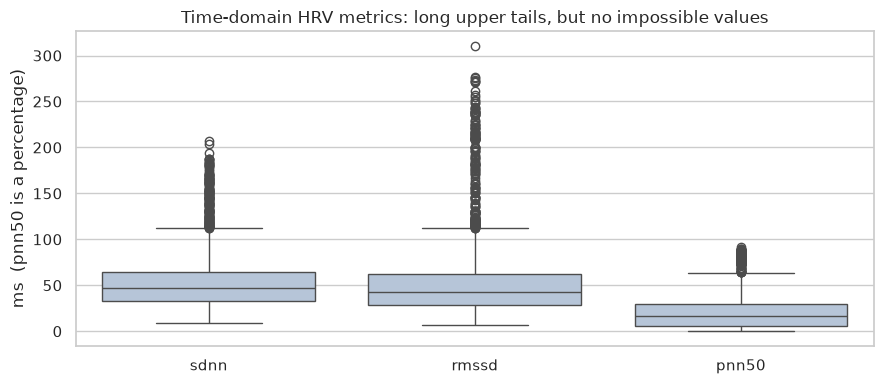

In [12]:
# A boxplot shows what those rules are reacting to
plt.figure(figsize=(9, 4))
sns.boxplot(data=hrv[["sdnn", "rmssd", "pnn50"]], color="lightsteelblue")
plt.title("Time-domain HRV metrics: long upper tails, but no impossible values")
plt.ylabel("ms  (pnn50 is a percentage)")
plt.tight_layout()
plt.show()

Both rules flag a lot, and the IQR one flags way more — 382 rows on `lfhf` against 53 for the 3-sigma
rule. That gap is the interesting part. They disagree because neither of their assumptions actually
holds here. The 3-sigma rule wants roughly normal data, and the standard deviation is being inflated by
the very tail it is supposed to be catching. The IQR rule wants rough symmetry, and on a right-skewed
distribution the upper fence ends up sitting much too close to the middle.

The boxplot shows what they are both reacting to, a long upper whisker with a spray of points past it.
But those values are all physically possible. Someone very relaxed really can have `hf` power in the
thousands. Deleting them would not be cleaning the data, it would be throwing away the signal.

So instead of a statistical rule I checked physiological limits, meaning values that genuinely cannot be
true.

In [13]:
checks = {"bpm outside 30-220": ((hrv["bpm"] < 30) | (hrv["bpm"] > 220)).sum(),
          "meanrr outside 300-2000ms": ((hrv["meanrr"] < 300) | (hrv["meanrr"] > 2000)).sum(),
          "sdnn <= 0": (hrv["sdnn"] <= 0).sum(),
          "rmssd <= 0": (hrv["rmssd"] <= 0).sum(),
          "pnn50 outside 0-100": ((hrv["pnn50"] < 0) | (hrv["pnn50"] > 100)).sum()}
pd.Series(checks).to_frame("rows violating")

,rows violating
bpm outside 30-220,0
meanrr outside 300-2000ms,0
sdnn <= 0,0
rmssd <= 0,0
pnn50 outside 0-100,0


In [14]:
# The HRV table comes back clean, but heart_rate was not filtered the same way
hr_bad = (heart_rate_clean["heart_rate"] < 25) | (heart_rate_clean["heart_rate"] > 250)
print("heart_rate range:", heart_rate_clean["heart_rate"].min(), "-", heart_rate_clean["heart_rate"].max())
print("impossible readings removed:", hr_bad.sum())
heart_rate_clean = heart_rate_clean[~hr_bad]

# And some heights cannot be real
tall = participants["height"] > 220
print()
display(participants.loc[tall, ["user_code", "height", "weight"]])
participants_clean = participants.copy()
participants_clean.loc[tall, "height"] = np.nan

heart_rate range: 10.0 - 232.0
impossible readings removed: 89



,user_code,height,weight
49,3fff7627ca,248.92,114.713
102,83161408c1,250.00,82.146


The HRV table passes every physiological check with zero violations, which says Welltory's own filtering
already did this job. The problems show up in the tables that did not go through it. `heart_rate` has
readings down to 10 bpm, which is not survivable, so those came out.

The heights are the bit I found most interesting. Two people are recorded over 220 cm, one of them at 250
cm, which is 8 foot 2, weighing 82 kg. Work out the BMI and you get 13.1. That is low, but it is not
obviously insane, so if I had filtered on BMI I would have sailed right past it. The error is only
visible if you look at the height itself. Lesson I am taking from that is to check the inputs before
building a feature on top of them, since a derived number can look reasonable while being made of
nonsense. I set the height to missing instead of dropping the person, because their HRV measurements are
perfectly good.

## 8. Transformation

Two things here. First a log transform on the skewed power columns. They are bounded at zero with a long
right tail, which is the standard case for logging, and the HRV literature already reports things as
`ln(RMSSD)` and `ln(HF)`, so it also makes my numbers comparable to published work.

Second, standardising within each person. This one matters more than it looks. Resting HRV varies hugely
between individuals — a fit 25 year old might sit at RMSSD 80 while someone older sits at 20 and neither
of them is sick. If I pool everyone together that between-person spread drowns out the within-person
changes, which are the thing I actually care about. Turning each measurement into a z-score inside that
person's own history asks the better question, which is whether this reading is unusual for them.

In [15]:
log_cols = ["sdnn", "rmssd", "lf", "hf", "vlf", "total_power"]
for c in log_cols:
    hrv_clean["log_" + c] = np.log(hrv_clean[c])
display(pd.DataFrame({"skew_before": hrv_clean[log_cols].skew().round(2),
                      "skew_after": hrv_clean[["log_" + c for c in log_cols]].skew()
                                    .set_axis(log_cols).round(2)}))

hrv_clean["measurement_datetime"] = pd.to_datetime(hrv_clean["measurement_datetime"])
hrv_clean["date"] = hrv_clean["measurement_datetime"].dt.normalize()

# Only do the z-score for people with enough measurements for a baseline to mean anything
enough = hrv_clean.groupby("user_code")["rmssd"].transform("count") >= 5
hrv_clean["rmssd_z"] = np.nan
hrv_clean.loc[enough, "rmssd_z"] = (hrv_clean.loc[enough].groupby("user_code")["log_rmssd"]
                                    .transform(lambda s: (s - s.mean()) / s.std()))
print("participants with 5 or more measurements:", hrv_clean.loc[enough, "user_code"].nunique(), "of 185")

,skew_before,skew_after
sdnn,1.72,-0.06
rmssd,2.66,0.30
lf,3.80,-0.27
hf,5.34,0.22
vlf,6.05,-0.38
total_power,3.79,-0.02


participants with 5 or more measurements: 85 of 185


Skew drops from as high as 6.1 down to roughly nothing. I did not need a +1 offset since every column's
minimum is already above zero.

## 9. New feature: days_since_onset

For each HRV measurement this is the number of days between when it was taken and when that person said
their symptoms started. Negative means before symptoms, 0 is the onset day, positive is during or after.

The reason I built it is that calendar dates are useless for comparing people here. One person got sick
in March and another in May, so April 15th has no shared meaning. What the research question needs is
where in their own illness each measurement sits, so that day 3 for one person lines up with day 3 for
another.

The catch is that this depends entirely on `symptoms_onset`, which from the quality section is the least
trustworthy column in the whole dataset. So the anchor has to be cleaned first, otherwise the feature
inherits all of its problems.

In [16]:
# Throw out the onset dates that fall outside the study before using them for anything
onset_clean = pd.to_datetime(participants_clean["symptoms_onset"], format="%m/%d/%Y", errors="coerce")
in_window = onset_clean.between(pd.Timestamp("2019-12-01"), pd.Timestamp("2020-07-01"))
participants_clean["onset_date"] = onset_clean.where(in_window)
print("onset dates reported:", onset_clean.notna().sum(),
      "| thrown out:", (onset_clean.notna() & ~in_window).sum(),
      "| usable:", participants_clean["onset_date"].notna().sum())

hrv_clean = hrv_clean.merge(participants_clean[["user_code", "onset_date"]], on="user_code", how="left")
hrv_clean["days_since_onset"] = (hrv_clean["date"] - hrv_clean["onset_date"]).dt.days
print("measurements that now have a timeline position:",
      hrv_clean["days_since_onset"].notna().sum(), "of", len(hrv_clean))
print()
print(hrv_clean["days_since_onset"].describe().round(1).to_string())

# Second feature, BMI, which only works because of the height fix earlier
participants_clean["bmi"] = participants_clean["weight"] / (participants_clean["height"] / 100) ** 2
print()
print("BMI computed for", participants_clean["bmi"].notna().sum(), "participants, median",
      round(participants_clean["bmi"].median(), 1))

onset dates reported: 147 | thrown out: 13 | usable: 134
measurements that now have a timeline position: 2685 of 3245

count    2685.0
mean        9.8
std        46.8
min      -128.0
25%        -9.0
50%        20.0
75%        40.0
max        97.0

BMI computed for 181 participants, median 26.3


Cleaning the anchor first is the whole reason this works. Before I did that the range ran from -726 to
19,465 days, which would have meant someone measuring their HRV 53 years after catching COVID. Afterwards
it looks sensible.

I deliberately kept a wide window rather than cutting down to just the illness period, because the
measurements from before onset are honestly the most valuable rows in here. They are the personal
baseline, and without them there is nothing to compare the sick days against.

## 10. Visualisations and relationships between variables

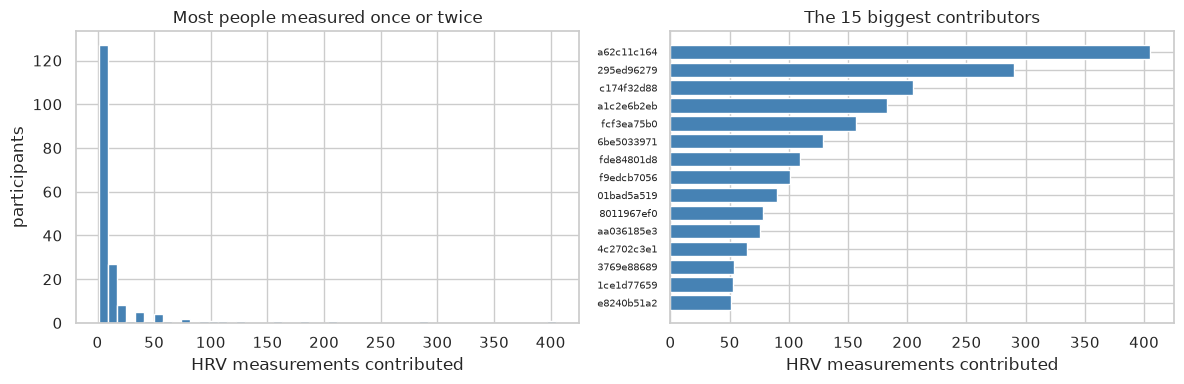

median per participant: 4 | people with only one: 54 of 185 | top 10 account for 54% of all rows


In [17]:
per_user = hrv_clean.groupby("user_code").size()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(per_user, bins=50, color="steelblue", edgecolor="white")
ax[0].set_xlabel("HRV measurements contributed")
ax[0].set_ylabel("participants")
ax[0].set_title("Most people measured once or twice")

top = per_user.sort_values(ascending=False).head(15)
ax[1].barh(range(len(top)), top.values, color="steelblue")
ax[1].set_yticks(range(len(top)))
ax[1].set_yticklabels(top.index, fontsize=7)
ax[1].invert_yaxis()
ax[1].set_xlabel("HRV measurements contributed")
ax[1].set_title("The 15 biggest contributors")
plt.tight_layout()
plt.show()

print("median per participant:", int(per_user.median()),
      "| people with only one:", (per_user == 1).sum(), "of", len(per_user),
      "| top 10 account for", f"{per_user.nlargest(10).sum()/per_user.sum():.0%}", "of all rows")

If there is one thing to take away from this notebook it is this plot. The median person contributed 4
measurements. The single biggest contributor did 405. The top ten people between them account for 54% of
every row in the table.

That creates a pseudo-replication problem. If I pool all 3,245 rows and run a test on them, I am not
testing 3,245 independent observations, I am mostly testing about ten people over and over again. Any
correlation I computed that way would largely be describing whoever measured the most. That is the
reason I standardised within each person earlier, and it is also why a serious model on this data would
need to group by participant rather than treating rows as independent.

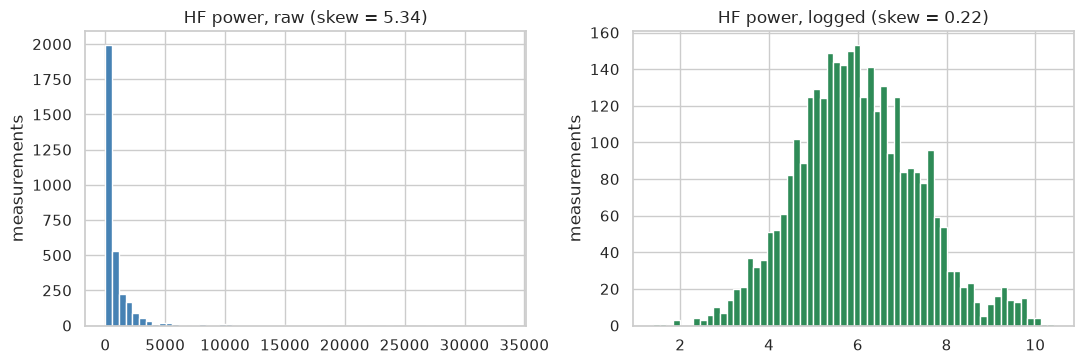

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(hrv_clean["hf"], bins=60, color="steelblue", edgecolor="white")
ax[0].set_title(f"HF power, raw (skew = {hrv_clean['hf'].skew():.2f})")
ax[1].hist(hrv_clean["log_hf"], bins=60, color="seagreen", edgecolor="white")
ax[1].set_title(f"HF power, logged (skew = {hrv_clean['log_hf'].skew():.2f})")
for a in ax:
    a.set_ylabel("measurements")
plt.tight_layout()
plt.show()

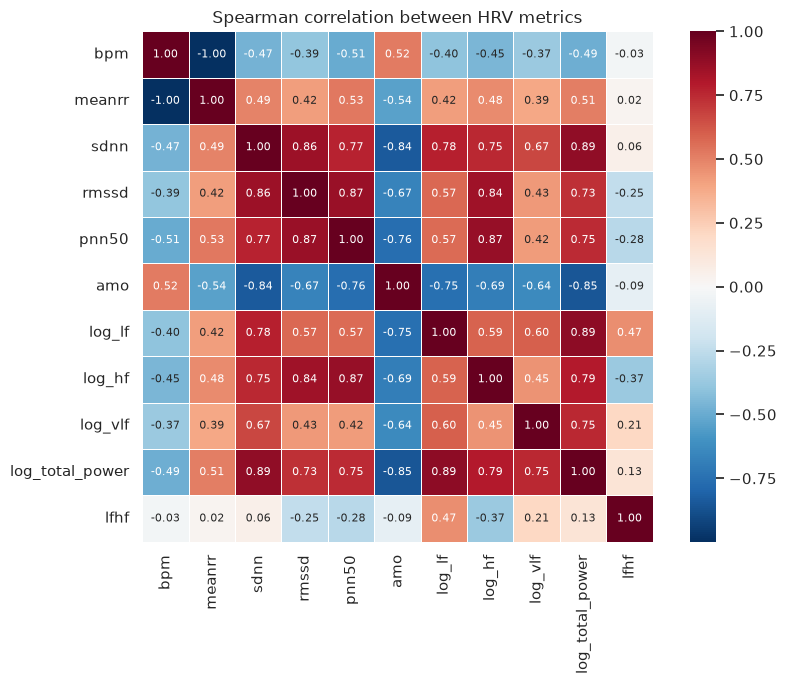

In [19]:
corr_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "amo",
             "log_lf", "log_hf", "log_vlf", "log_total_power", "lfhf"]
plt.figure(figsize=(9, 7))
sns.heatmap(hrv_clean[corr_cols].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title("Spearman correlation between HRV metrics")
plt.tight_layout()
plt.show()

The raw HF histogram is squashed up against the left edge with a long tail trailing off, and after
logging it looks close to symmetric. That is the transform doing the job that deleting outliers would
have done badly.

For the correlations I used Spearman instead of Pearson, since a few of these are still non-linear with
respect to each other even after logging and Spearman only needs the relationship to be monotonic.

It mostly confirms what the physiology says it should:

- `bpm` and `meanrr` come out at -1.00, which they have to, since one is literally 60000 divided by the
  other. Putting both into a model would be pointless.
- `rmssd`, `pnn50` and `log_hf` sit in a tight cluster around 0.84 to 0.87. They really are three
  different names for close to the same parasympathetic quantity.
- `amo` runs strongly negative against everything else (-0.84 with `sdnn`), which makes sense, since a
  rhythm concentrated into one bin is by definition not very variable.
- `lfhf` only tracks the two things it is built from and sits near zero against everything else, so it is
  not adding much information of its own.

Practically that means these 11 columns are carrying something like three independent dimensions, not
eleven.

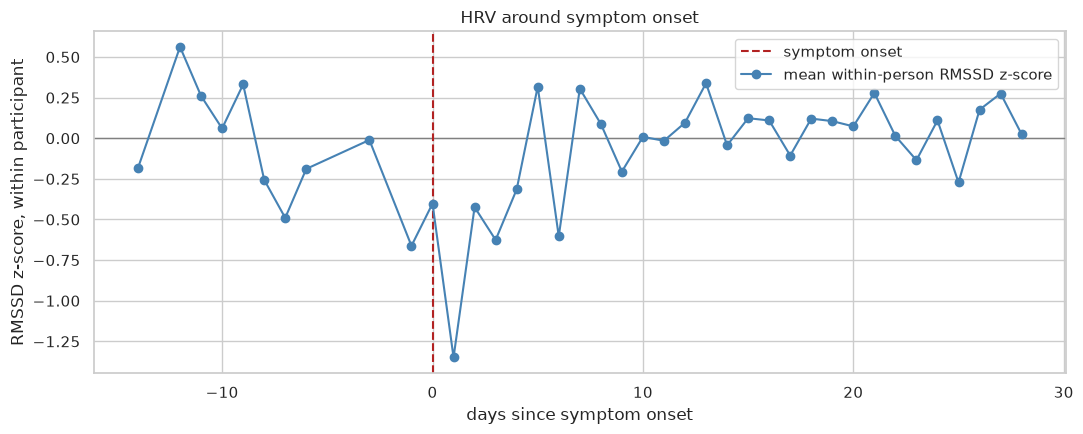

measurements in the window: 920 | participants: 51


In [20]:
window = hrv_clean[hrv_clean["days_since_onset"].between(-14, 28) & hrv_clean["rmssd_z"].notna()]
daily = window.groupby("days_since_onset")["rmssd_z"].agg(["mean", "count"])
daily = daily[daily["count"] >= 5]     # ignore days that only one or two people contributed to

plt.figure(figsize=(11, 4.5))
plt.axhline(0, color="grey", linewidth=1)
plt.axvline(0, color="firebrick", linestyle="--", linewidth=1.5, label="symptom onset")
plt.plot(daily.index, daily["mean"], marker="o", color="steelblue",
         label="mean within-person RMSSD z-score")
plt.xlabel("days since symptom onset")
plt.ylabel("RMSSD z-score, within participant")
plt.title("HRV around symptom onset")
plt.legend()
plt.tight_layout()
plt.show()

print("measurements in the window:", len(window), "| participants:", window["user_code"].nunique())

Each point is the average standardised RMSSD across everyone for that day of their illness, and I dropped
any day with fewer than 5 measurements so one person could not swing a point on their own. There is a
visible dip around onset that comes back up over the next few weeks.

I do want to be careful about overselling this. The line is noisy, the set of people contributing changes
from day to day, and the whole thing rests on self-reported onset dates in a convenience sample. It is a
reasonable exploratory picture and it is roughly the shape the published papers on this dataset found,
but on its own it is not evidence of anything.

## 11. Summary

185 self-selected app users tracked their HRV, symptoms and wearable data between December 2019 and June
2020, to see whether HRV shifts around a COVID infection.

Structurally the data is in good shape. No orphaned foreign keys, participant IDs are unique, no fully
duplicated rows, and the HRV metrics are internally consistent when checked against each other. The
problems are all in the contents, and nearly all of them come from things people typed in:

| Problem | How much | What I did |
|---|---|---|
| Onset dates outside the study period, 1967 through 2022 | 13 participants | rejected before building the timeline feature |
| Duplicate (user, timestamp) heart rate readings | 7,330 | averaged the collisions |
| Impossible heart rates, down to 10 bpm | 89 | removed |
| Heights over 220 cm, one at 250 cm | 2 participants | set to missing before computing BMI |
| Codebook join key with a newline and non-breaking space in it | 1 key | stripped before joining |
| Same survey question answered twice in a day | 24 | kept the later answer |

The four decisions I would most want to defend:

1. Keeping the -1 and -2 values in `how_feel` instead of treating them as missing codes. They are Likert
   points, and dropping them would have deleted the measurements taken when people felt worst.
2. Dropping the sparse wearable columns rather than imputing them, because their missingness depends on
   what device someone owned, so imputing would smuggle income in as physiology.
3. Log transforming the skewed columns instead of deleting outliers. Both standard outlier rules flagged
   hundreds of rows that were merely high rather than wrong.
4. Standardising within each participant, because with 54% of the data coming from ten people, pooled
   statistics would mostly be describing those ten.

The thing that limits this dataset most is not any of the errors above, since those are all fixable. It
is the sampling. A self-selected convenience sample, no control group, self-reported COVID status at a
time when tests were scarce, and a median of 4 measurements per person. It supports looking at
within-person change over time. It does not support saying anything general about COVID and HRV in the
population.